In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
sns .set(style="whitegrid")
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans , DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_csv('/kaggle/input/mall-customers-segmentation/Mall_Customers.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
encoder=LabelEncoder()
df['Genre']=encoder.fit_transform(df['Genre'])

In [7]:
# scaler= StandardScaler()
# df_scaled=scaler.fit_transform(df.iloc[:,1:])

In [8]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [9]:
inertia=[]
for i in range(1,11):
    model=KMeans(n_clusters=i)
    model.fit(df.iloc[:,1:])
    inertia.append(model.inertia_)

In [10]:
inertia

[308862.06000000006,
 219942.0585079462,
 143391.59236035676,
 110045.92297541516,
 79309.98781376517,
 69357.26908023775,
 52124.560915289076,
 47798.72983950634,
 41167.80334856037,
 42608.89855308089]

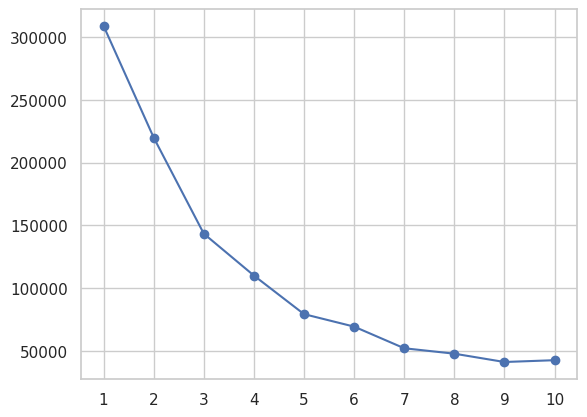

In [11]:
plt.plot(range(1,11),inertia,marker='o')
plt.xticks([i for i in range (1,11)])
plt.show()

#### **KMeans Model**

In [12]:
# kmodel=KMeans(n_clusters=6 ,random_state=42)
# kmodel.fit(df.iloc[:,1:])


In [13]:
# df['label']=kmodel.predict(df.iloc[:,1:])

In [14]:
kmodel=KMeans(n_clusters=6 ,random_state=42)
df['label']=kmodel.fit_predict(df.iloc[:,1:])

In [15]:
kmeans_score=silhouette_score(df.iloc[:,1:-1],kmodel.labels_)
print(f'K_means score = {kmeans_score:.2f}')

K_means score = 0.42


In [16]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),label
0,1,1,19,15,39,5
1,2,1,21,15,81,2
2,3,0,20,16,6,5
3,4,0,23,16,77,2
4,5,0,31,17,40,5
...,...,...,...,...,...,...
195,196,0,35,120,79,1
196,197,0,45,126,28,3
197,198,1,32,126,74,1
198,199,1,32,137,18,3


In [17]:
summary=df.groupby('label').agg(
    average_age=('Age','mean'),
    average_income=('Annual Income (k$)','mean'),
    average_spending_score=('Spending Score (1-100)','mean'),
    count_customers=('Age','count')
)

summary

,average_age,average_income,average_spending_score,count_customers
label,,,,
0,43.934211,55.210526,49.447368,76
1,32.200000,109.700000,82.000000,10
2,24.960000,28.040000,77.000000,25
3,40.324324,87.432432,18.189189,37
4,32.862069,78.551724,82.172414,29
5,45.217391,26.304348,20.913043,23


#### **DBSCAN**

In [18]:
dbscan=DBSCAN(eps=12,min_samples=10)
df['dbscan']=dbscan.fit_predict(df.iloc[:,1:-1])

In [19]:
# dbscan.labels_
# df['dbscan'].nunique()
df['dbscan'].unique()

array([-1,  0,  1,  2])

In [20]:
dbscan_labels=df['dbscan']
valid_mask= dbscan_labels != -1     # mask for true,false values
valid_features= df[valid_mask]          # [] as a gate : true accepted , false not accepted
valid_labels=dbscan_labels[valid_mask]    # [] as a gate : true accepted , false not accepted


In [21]:
if len(np.unique(valid_labels)) > 1:    # to make sure num of groups > 1  
    dbscan_score = silhouette_score(valid_features, valid_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.2f}")
else:
    print("DBSCAN produced too many noise points. No valid clusters found.")

DBSCAN Silhouette Score: 0.50
